# Likelihood Estimation for the g-and-k Distribution

*Author: Stefan T. Radev*

In most BayesFlow workflows the target of learning is the **posterior** $p(\theta \mid x)$. Differently, in this tutorial we learn the **likelihood** $p(x \mid \theta)$ - the distribution of observations *given* parameters. We demonstrate how to easily plug the learned likelihood into a PyMC workflow.

## A Real Challenge: Intractable Likelihoods

Many quantities in science are defined through simulation rather than a closed-form density. The **g-and-k distribution** is a textbook example: it is flexible enough to model arbitrary skewness and kurtosis, but its probability density function **has no closed-form expression**.

For traditional MCMC (e.g., via PyMC) this creates a problem, since `pm.CustomDist` requires a `logp` function. BayesFlow solves this by *learning* the likelihood from simulations with a generative network, after which the learned *differentiable* density plugs directly into NUTS or any other sampler. 

## The Model

We observe $n$ **bivariate** samples from a g-and-k model with Gaussian-copula dependence:

$$x_i \overset{\text{i.i.d.}}{\sim} \text{g-and-k}(g,\,k,\,\rho), \qquad i = 1, \ldots, n$$

Each marginal follows a g-and-k distribution with shared shape parameters $(g, k)$, and the two dimensions are coupled through a Gaussian copula with correlation $\rho$. The parameters are summarized in the table below:

| Parameter | Meaning | Prior |
|---|---|---|
| $g$ | asymmetry ($g>0$ → right-skewed) | $\text{Uniform}(-1.5,\;1.5)$ |
| $k$ | tail weight ($k>0$ → heavier tails) | $\text{Uniform}(0,\;1.5)$ |
| $\rho$ | copula correlation | $\text{Uniform}(-0.9,\;0.9)$ |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import special

import bayesflow as bf

INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': UNIMPLEMENTED: LoadPjrtPlugin is not implemented on windows yet.
INFO:bayesflow:Using backend 'jax'


In [2]:
rng = np.random.default_rng(2026)


def gnk_quantile(u, a, b, g, k, c=0.8):
    """Quantile (percent-point) function of the g-and-k distribution.

    Parameters
    ----------
    u : array-like, values in (0, 1)
    a : location
    b : scale  (> 0)
    g : asymmetry  (g > 0 -> right-skewed, g < 0 -> left-skewed)
    k : tail weight  (k > 0 -> heavier tails than Gaussian)
    c : standard constant, default 0.8 per Rayner & MacGillivray (2002)
    """
    z = special.ndtri(u)
    return a + b * (1 + c * np.tanh(g * z / 2)) * (1 + z**2)**k * z


def sample_bivariate_gnk(g, k, rho, n, rng_inst):
    """Draw n bivariate samples from the g-and-k Gaussian-copula model.

    Both marginals share the same (g, k) shape parameters.
    Dependence is introduced via a Gaussian copula with correlation rho.
    """
    cov = np.array([[1.0, rho], [rho, 1.0]])
    z = rng_inst.multivariate_normal([0.0, 0.0], cov, size=n)
    u = np.clip(special.ndtr(z), 1e-4, 1 - 1e-4)
    return gnk_quantile(u, a=0.0, b=1.0, g=g, k=k)

## 1. The g-and-k Distribution Family

The g-and-k distribution is defined entirely through its **quantile function**:

$$Q(p \mid a, b, g, k) = a + b\!\left(1 + c \cdot \tanh\!\left(\tfrac{g\,z(p)}{2}\right)\right)(1 + z(p)^2)^k\,z(p)$$

where $z(p) = \Phi^{-1}(p)$ is the standard-normal quantile and $c = 0.8$.

- **$g = 0,\;k = 0$** → reduces to a Gaussian  
- **$g > 0$** → right-skewed; **$g < 0$** → left-skewed  
- **$k > 0$** → heavier tails than Gaussian  

### Why the Likelihood is Intractable?

Computing the PDF requires *inverting* $Q$ numerically:

$$p(x \mid a,b,g,k) = \frac{1}{Q'\!\left(Q^{-1}(F(x))\right)}$$

There is no closed form for $Q^{-1}$, so evaluating the log-likelihood for $n$ observations requires solving $n$ scalar root-finding problems. Computing gradients through them for NUTS is an additional challenge.

Simulation-based inference with BayesFlow sidesteps this entirely. We **simulate** from the model and train a neural network to approximate $p(x \mid g,k,\rho)$ directly.

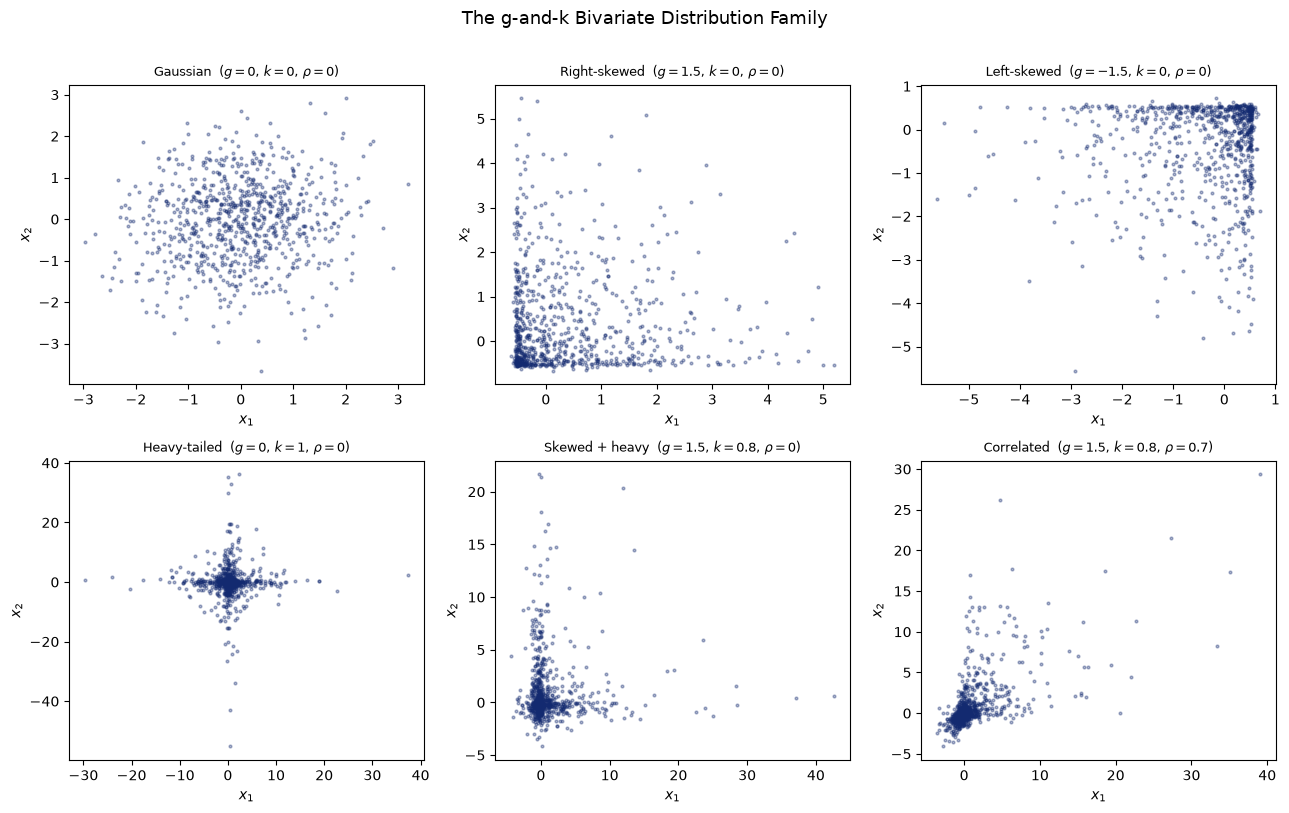

In [3]:
vis_rng = np.random.default_rng(42)

configs = [
    (0.0,  0.0,  0.0,  r"Gaussian  ($g=0,\,k=0,\,\rho=0$)"),
    (1.5,  0.0,  0.0,  r"Right-skewed  ($g=1.5,\,k=0,\,\rho=0$)"),
    (-1.5, 0.0,  0.0,  r"Left-skewed  ($g=-1.5,\,k=0,\,\rho=0$)"),
    (0.0,  1.0,  0.0,  r"Heavy-tailed  ($g=0,\,k=1,\,\rho=0$)"),
    (1.5,  0.8,  0.0,  r"Skewed + heavy  ($g=1.5,\,k=0.8,\,\rho=0$)"),
    (1.5,  0.8,  0.7,  r"Correlated  ($g=1.5,\,k=0.8,\,\rho=0.7$)"),
]

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for ax, (g, k, rho, title) in zip(axes.flat, configs):
    samp = sample_bivariate_gnk(g, k, rho, 800, vis_rng)
    ax.scatter(samp[:, 0], samp[:, 1], s=4, alpha=0.35, color="#132a70")
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")

fig.suptitle("The g-and-k Bivariate Distribution Family", fontsize=13, y=1.01)
fig.tight_layout()

## 2. Training the Likelihood Approximator

### Defining the Simulator

Each call to `gnk_simulator` draws a **single bivariate observation** from the g-and-k model at a randomly-sampled parameter set $(g, k, \rho)$. We use priors that do not land us in the "near-infinite-variance" regime.

Because the $n$ observations we will use for inference are **exchangeable** (i.i.d. given the parameters), BayesFlow only needs to learn the single-observation likelihood $p(x_i \mid g, k, \rho)$ for $x_i \in \mathbb{R}^2$. During PyMC integration the `NeuralDistribution` wrapper automatically sums the per-observation log-probabilities over all $n$ data points.

In [4]:
def prior():
    g   = rng.uniform(-1.0, 1.0)
    k   = rng.uniform(0.0,  0.5)
    rho = rng.uniform(-0.9, 0.9)
    return {"g": g, "k": k, "rho": rho}

def gnk_simulator(g, k, rho):
    """Draw one bivariate observation from the g-and-k copula model."""
    cov = np.array([[1.0, rho], [rho, 1.0]])
    z = rng.multivariate_normal([0.0, 0.0], cov)
    u = np.clip(special.ndtr(z), 1e-4, 1 - 1e-4)
    x = gnk_quantile(u, a=0.0, b=1.0, g=g, k=k)
    return {"x": np.clip(x, -10.0, 10.0)}


simulator = bf.make_simulator([prior, gnk_simulator])

In [5]:
test_batch = simulator.sample(3)
print("x   shape:", test_batch["x"].shape)
print("g   shape:", test_batch["g"].shape)
print("k   shape:", test_batch["k"].shape)
print("rho shape:", test_batch["rho"].shape)

x   shape: (3, 2)
g   shape: (3, 1)
k   shape: (3, 1)
rho shape: (3, 1)


### Training Setup

The network models $p(x \mid g, k, \rho)$ where $x \in \mathbb{R}^2$. For demonstration purposes, we train a *normalizing flow* with a spline transform (i.e., a "neural spline flow"). Despite developments in free-form architecture, such as [diffusion models](https://arxiv.org/abs/2512.20685), normalizing flows are still attractive because they can perform single-step density evaluation. The variable roles are **reversed** compared to posterior estimation:

| Role | Variable | Meaning |
|---|---|---|
| `inference_variables` | $x$ | what the network models (the 2-D observation) |
| `inference_conditions` | $[g,\,k,\,\rho]$ | the conditioning parameters |

We pass the three parameters as separate keys; BayesFlow's adapter automatically concatenates them into a single conditions vector before passing to the network.

Training takes approximately **4-5 minutes** with JAX on a CPU and around 20 seconds on GPU.

In [8]:
workflow = bf.BasicWorkflow(
    simulator=simulator,
    inference_network=bf.networks.CouplingFlow(
        transform="spline", 
        depth=2,
        # For heavier-tail likelihoods, you can play around with
        # base_distribution=bf.distributions.DiagonalStudentT(df=20),
    ),
    inference_variables="x",
    inference_conditions=["g", "k", "rho"],
    standardize="all",
)

In [9]:
history = workflow.fit_online(
    epochs=10,
    num_batches_per_epoch=100,
    batch_size=256, 
    validation_data=1024
)

INFO:bayesflow:Fitting on dataset instance of OnlineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - loss: 2.6624 - val_loss: 2.4931
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - loss: 2.4566 - val_loss: 2.3680
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - loss: 2.3392 - val_loss: 2.2879
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 2.3238 - val_loss: 2.2771
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 2.2800 - val_loss: 2.2514
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 2.2870 - val_loss: 2.2444
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 2.2777 - val_loss: 2.2379
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 2.2711 - val_loss: 2.2419
Epoch 9/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 2.2754 - val_loss: 2.2387
Epoch 10/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 2.2673 - val_loss: 2.2383


INFO:bayesflow:Training completed in 36.51 seconds.


Let's briefly inspect convergence. The loss curve should resemble a smooth exponential decay.

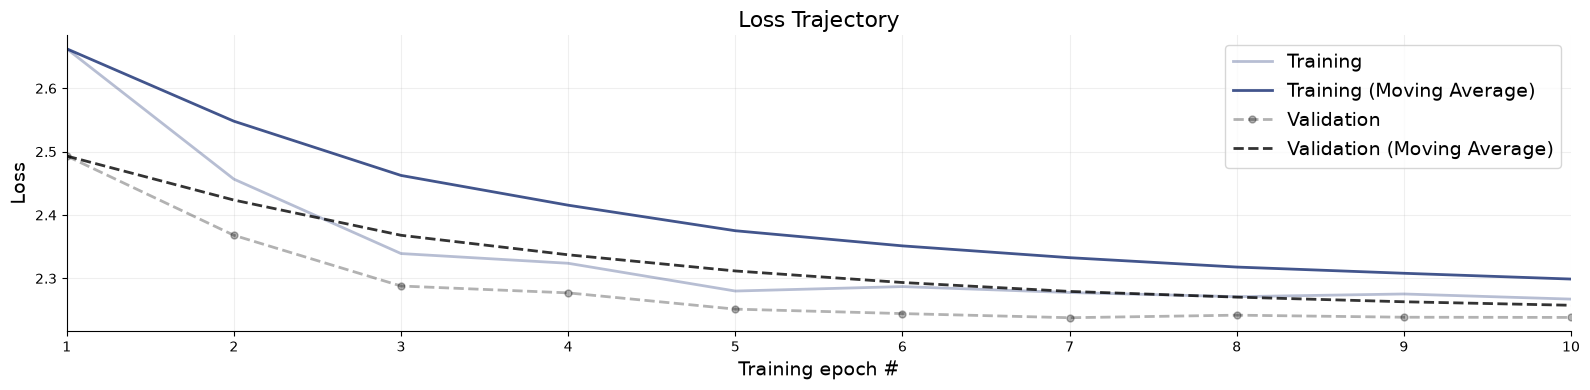

In [10]:
f = bf.diagnostics.plots.loss(history)

## 3. Evaluating the Learned Likelihood

### Comparing Simulator and Flow Samples

As a quick check, we fix $\theta^\star = (g=0.9,\;k=0.4,\;\rho=0.5)$, a right-skewed, moderately heavy-tailed, positively-correlated bivariate distribution. We then draw 800 samples from both:

- **Simulator** (ground truth): exact samples from the g-and-k model via the quantile function  
- **Trained flow** (approximation): samples from the learned likelihood

The two scatter plots should be nearly indistinguishable, confirming the flow captures the distributional shape correctly.

In [11]:
g_star, k_star, rho_star = 0.9, 0.4, 0.5

true_samples = sample_bivariate_gnk(g_star, k_star, rho_star, n=5000, rng_inst=rng)

In [12]:
approx = workflow.sample(
    num_samples=5000,
    conditions={
        "g":   np.array([[g_star]]),
        "k":   np.array([[k_star]]),
        "rho": np.array([[rho_star]]),
    },
)
approx_x = approx["x"][0]
print("approx_x shape:", approx_x.shape)

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Sampling completed in 3.89 seconds.


approx_x shape: (5000, 2)


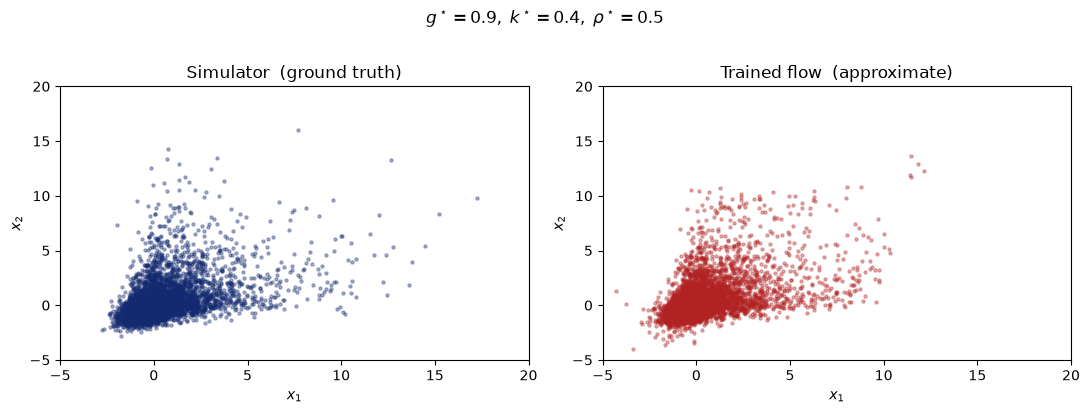

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, samp, title, color in zip(
    axes,
    [true_samples, approx_x],
    ["Simulator  (ground truth)", "Trained flow  (approximate)"],
    ["#132a70", "#b22222"],
):
    ax.scatter(samp[:, 0], samp[:, 1], s=5, alpha=0.35, color=color)
    ax.set_title(title)
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.set_ylim([-5, 20])
    ax.set_xlim([-5, 20])

fig.suptitle(
    rf"$g^\star={g_star},\; k^\star={k_star},\; \rho^\star={rho_star}$",
    y=1.02,
)
fig.tight_layout()

## 4. Downstream Integration with PyMC

### Plugging the Learned Likelihood into NUTS

BayesFlow's `NeuralDistribution` wrapper registers the trained flow as a PyMC-compatible custom distribution.  We:

1. Simulate $n = 50$ bivariate observations at known true parameters $\theta^\star$
2. Place broad priors on $(g, k, \rho)$ in a PyMC model
3. Run NUTS to recover the posterior $p(g, k, \rho \mid x_{1:50})$

Because the observations are i.i.d., `NeuralDistribution` with `exchangeable=True` (the default) automatically **vmaps** the per-observation log-likelihood and sums the results. No manual looping is needed. The `param_names` argument specifies the order in which PyMC variables are forwarded to the network:

$$q(\theta \mid x_{1:50}) \propto \underbrace{\prod_{i=1}^{50}q(x_i \mid g, k, \rho)}_{\text{neural likelihood}} \cdot \underbrace{p(g)\,p(k)\,p(\rho)}_{\text{PyMC priors}}$$

In [14]:
import pymc as pm
import arviz as az

from bayesflow.wrappers.pymc import NeuralDistribution

# Simulate a "real" dataset at known true parameters
g_true, k_true, rho_true = 0.8, 0.3, 0.5
observed_data = sample_bivariate_gnk(g_true, k_true, rho_true, n=50, rng_inst=rng)
print(f"Observed data shape: {observed_data.shape}")

INFO:pytensor.configparser:Suppressed KeyError in PyTensorConfigParser.add for parameter 'cxx'!
INFO:pytensor.configparser:Suppressed KeyError in PyTensorConfigParser.add for parameter 'gcc_version_str'!
INFO:pytensor.configparser:Suppressed KeyError in PyTensorConfigParser.add for parameter 'compile__timeout'!
INFO:pytensor.configparser:Suppressed KeyError in PyTensorConfigParser.add for parameter 'DebugMode__check_c'!
INFO:pytensor.configparser:Suppressed KeyError in PyTensorConfigParser.add for parameter 'compiledir'!
INFO:pytensor.configparser:Suppressed KeyError in PyTensorConfigParser.add for parameter 'blas__ldflags'!
INFO:arviz:Found 'auto' as default backend, checking available backends
INFO:arviz:Matplotlib is available, defining as default backend
INFO:arviz:arviz_base 1.3.0 available, exposing its functions as part of the `arviz` namespace
INFO:arviz:arviz_stats 1.3.0 available, exposing its functions as part of the `arviz` namespace
INFO:arviz:arviz_plots 1.3.0 available, 

Observed data shape: (50, 2)


In [15]:
neural_dist = NeuralDistribution(
    approximator=workflow.approximator,
    param_names=["g", "k", "rho"],
    exchangeable=True
)

In [16]:
with pm.Model() as gnk_model:
    g   = pm.Uniform("g",   lower=-1.0, upper=1.0)
    k   = pm.Uniform("k",   lower=0.0,  upper=0.5)
    rho = pm.Uniform("rho", lower=-0.9, upper=0.9)

    obs = neural_dist("obs", g=g, k=k, rho=rho, observed=observed_data)

    # Setting cores=4 naively on Linux will fork() and give you troubles
    trace = pm.sample(
        draws=1000,
        tune=1000,
        nuts_sampler="pymc",
        chains=4,
        cores=4,
        random_seed=42,
    )

c:\Users\radevs\Desktop\Projects\MBNCS26\Day5-SBI\.venv\Lib\site-packages\pytensor\gradient.py:1327: FutureWarning: RatioLogpOp should implement `pullback` instead of `L_op`/`grad`. Direct `L_op`/`grad` implementations are deprecated and will stop being called in a future version.
  input_grads = node.op.pullback(inputs, node.outputs, new_output_grads)
INFO:pymc.sampling.mcmc:Initializing NUTS using jitter+adapt_diag...
INFO:c:\Users\radevs\Desktop\Projects\MBNCS26\Day5-SBI\.venv\Lib\site-packages\pytensor\link\c\lazylinker_c.py:Compiling new CVM
INFO:pytensor.link.c.cmodule:g++ -march=native selected lines: ['C:/rtools40/mingw64/bin/../lib/gcc/x86_64-w64-mingw32/8.3.0/cc1.exe -E -quiet -v -iprefix C:/rtools40/mingw64/bin/../lib/gcc/x86_64-w64-mingw32/8.3.0/ -D_REENTRANT - -march=icelake-client -mmmx -mno-3dnow -msse -msse2 -msse3 -mssse3 -mno-sse4a -mcx16 -msahf -mmovbe -maes -msha -mpclmul -mpopcnt -mabm -mno-lwp -mfma -mno-fma4 -mno-xop -mbmi -mno-sgx -mbmi2 -mno-pconfig -mno-wbnoin

Output()

INFO:pymc.sampling.mcmc:Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 94 seconds.


### Recovering the True Parameters

NUTS should recover posteriors concentrated near the true values $(g^\star=1.2,\; k^\star=0.7,\; \rho^\star=0.5)$.

With only $n = 50$ observations the posteriors will be moderately wide, reflecting *epistemic uncertainty* about the shape parameters + *approximation error* due to the neural likelihood. The vertical lines in the posterior plots below mark the simulated ground-truths.

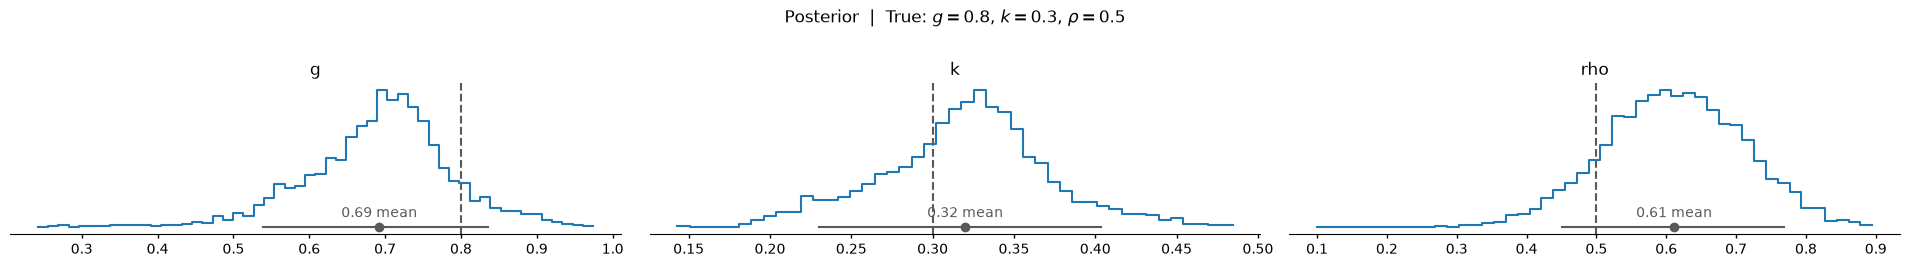

In [22]:
pc = az.plot_dist(
    trace,
    var_names=["g", "k", "rho"],
    kind="hist",
)

az.add_lines(
    pc,
    values={
        "g": g_true,
        "k": k_true,
        "rho": rho_true,
    },
)

plt.suptitle(
    rf"Posterior  |  True: $g={g_true}$, $k={k_true}$, $\rho={rho_true}$",
    y=1.02,
)
plt.tight_layout()

### Postscript

Neural Likelihood Estimation (NLE) with a `ContinuousApproximator` is not the only way you can connect BayesFlow networks with PyMC. Alternatively, and sometimes more stably, you can apply Neural Ratio Estimation (NRE) with a [classifier trick](https://arxiv.org/abs/2210.06170) to learn the likelihood-to-evidence ratio $p(x \mid \theta) / p(x)$. This is demonstrated in a great detail in our [tutorial or NRE](./Ratio_Estimation.ipynb) featuring further ways to leverage the flexibility of learning a likelihood-like object.